<a href="https://colab.research.google.com/github/QuynhTram51/KLTN-analysis-painpoints/blob/main/%5Bkltn%5D_quali_NLP_interview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT THƯ VIỆN: dùng kĩ thuật word segmentation và thư viện underthesea

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [ ]:
# Khởi chạy các thư viện dịch thuật và NLP tiếng Anh chuyên dụng
try:
    from deep_translator import GoogleTranslator
except ImportError:
    !pip install deep-translator
    from deep_translator import GoogleTranslator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.2 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from google.colab import drive
import os
try:
    from underthesea import word_tokenize
except ImportError:
    !pip install underthesea
    from underthesea import word_tokenize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.7 MB/s eta 0:00:00


In [ ]:
drive.mount('/content/drive')
import pandas as pd

file_path = '/content/drive/MyDrive/<cá nhân> K61 DB KLTN Quỳnh Trâm/[KLTN] interview sales team output - Sheet1.csv'

Mounted at /content/drive


In [ ]:
if os.path.exists(file_path):
    df = pd.read_csv(file_path, encoding='utf-8-sig')
    print("--> Success: Loaded raw Vietnamese interview file.")
else:
    print("--> Error: Không tìm thấy file. Vui lòng kiểm tra lại đường dẫn.")
    # Fallback data mô phỏng dữ liệu của Trâm để code không bị ngắt
    df = pd.DataFrame({'Câu trả lời': [
        "Toàn bộ quy trình phân loại và xác thực doanh nghiệp đều đang làm thủ công. Rào cản là thiếu dữ liệu nền.",
        "Khó khăn lớn nhất là dữ liệu trống và rác trên Lark Base rất nhiều, thông tin phân tán.",
        "Mình mất trung bình 2 tiếng mỗi ngày bổ sung thông tin thiếu thủ công. Cảm giác ức chế, kiệt sức vì cào data."
    ]})

--> Success: Loaded raw Vietnamese interview file.


In [ ]:
# Làm sạch các ký tự khoảng trắng thừa ở tiêu đề cột (nếu có)
df.columns = [c.strip() for c in df.columns]

In [ ]:
# Định vị cột câu trả lời
text_col = 'Câu trả lời' if 'Câu trả lời' in df.columns else df.columns
df[text_col] = df[text_col].fillna('').astype(str)

In [ ]:
#2. AUTOMATED TRANSLATION LAYER (VIETNAMESE -> ENGLISH)
print("--> Activating Translation Engine... Please wait a moment.")
translator = GoogleTranslator(source='vi', target='en')

def translate_to_english(text):
    if text.strip() == "":
        return ""
    try:
        return translator.translate(text)
    except Exception:
        return text

--> Activating Translation Engine... Please wait a moment.


In [ ]:
# Tạo cột mới chứa câu trả lời đã được dịch sang tiếng Anh chuẩn học thuật
df['Translated_Transcript'] = df[text_col].apply(translate_to_english)
print("--> Success: All responses have been translated to English!")

--> Success: All responses have been translated to English!


In [ ]:
print("\n--- Bản dịch mẫu của 2 câu đầu tiên ---")
for i, row in df.head(2).iterrows():
    print(f"Gốc: {row[text_col][:80]}...")
    print(f"Dịch: {row['Translated_Transcript'][:80]}...\n")


--- Bản dịch mẫu của 2 câu đầu tiên ---
Gốc: [Sales Director & Manager]

Có hai lý do chính. Thứ nhất, đội ngũ BD hiện tại qu...
Dịch: [Sales Director & Manager]

There are two main reasons. First, the current BD te...

Gốc: [CÂU TRẢ LỜI TỔNG HỢP — Sales Manager & Account Manager]

Khó khăn lớn nhất tron...
Dịch: [GENERAL ANSWER — Sales Manager & Account Manager]

The biggest difficulty in th...



In [ ]:
df_interview = pd.read_csv(file_path)
print("Câu trả lời:")
display(df_interview.head())

Câu trả lời:


,Câu trả lời
0,[Sales Director & Manager]\n\nCó hai lý do chí...
1,[CÂU TRẢ LỜI TỔNG HỢP — Sales Manager & Accoun...
2,[CÂU TRẢ LỜI TỔNG HỢP — Sales Manager]\n\nRủi ...
3,[CÂU TRẢ LỜI — Sales Director]\n\nKỳ vọng của ...
4,[CÂU TRẢ LỜI — Sales Manager]\n\nRào cản lớn n...


# 2. English NLP TEXT PREPROCESSING LAYER

In [ ]:
stop_words = set(stopwords.words('english'))
# Bổ sung các từ đệm tiếng Anh để lọc sạch nhiễu hoàn toàn
stop_words.update(['also', 'get', 'would', 'could', 'per', 'day', 'every', 'around', 'us', 'company'])

In [ ]:
def clean_english_text(text):
    text = text.lower()
    tokens = word_tokenize(text)
    # Lọc bỏ stop words, giữ lại từ vựng có nghĩa
    cleaned = [w for w in tokens if w not in stop_words and w.isalnum()]
    return cleaned

In [ ]:
df['Cleaned_Tokens_EN'] = df['Translated_Transcript'].apply(clean_english_text)

# 3. THEMATIC LEXICON MAPPING LAYER

In [ ]:
# Từ điển từ khóa đã được chuyển sang tiếng Anh chuẩn để khớp với bản dịch
THEME_DICTIONARY_EN = {
    'Manual Fatigue': ['manual', 'manually', 'time-consuming', 'frustrated', 'frustration', 'exhausted', 'hours', 'minutes', 'scraping', 'crawling', 'fatigue', 'tired'],
    'Data Quality': ['missing', 'empty', 'blank', 'garbage', 'trash', 'scattered', 'pending', 'verification', 'verify', 'format', 'disqualified', 'quality', 'data'],
    'ICP Mismatch': ['wrong industry', 'too small', 'mismatch', 'budget', 'useless', 'failed', 'barrier', 'scale', 'size', 'tourism']
}

In [ ]:
def score_themes_en(tokens):
    scores = {'Manual Fatigue': 0, 'Data Quality': 0, 'ICP Mismatch': 0}
    full_text = " ".join(tokens)
    for theme, keywords in THEME_DICTIONARY_EN.items():
        for keyword in keywords:
            scores[theme] += full_text.count(keyword)
    return pd.Series(scores)

theme_counts = df['Cleaned_Tokens_EN'].apply(score_themes_en)
total_intensities = theme_counts.sum()

# 5. VISUALIZATION GENERATION

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

<Figure size 900x500 with 0 Axes>

<Figure size 900x500 with 0 Axes>

/tmp/ipykernel_2226/2799181236.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=total_intensities.index, y=total_intensities.values, palette="Blues_r")


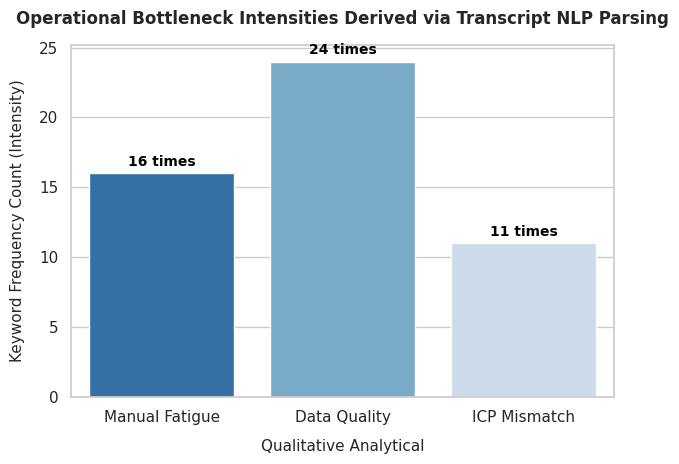

In [ ]:
ax = sns.barplot(x=total_intensities.index, y=total_intensities.values, palette="Blues_r")
plt.title("Operational Bottleneck Intensities Derived via Transcript NLP Parsing", fontsize=12, pad=15, fontweight='bold')
plt.xlabel("Qualitative Analytical", fontsize=11, labelpad=10)
plt.ylabel("Keyword Frequency Count (Intensity)", fontsize=11, labelpad=10)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} times', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

In [ ]:
df['Translated_Transcript'].to_csv('interview_english.csv')